In [1]:
!pip install xgboost -q
print("Ready ✅")

Ready ✅


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 100000

df = pd.DataFrame({
    'distance_km': np.round(np.random.uniform(0.5, 30, n), 2),
    'hour': np.random.randint(0, 24, n),
    'day_of_week': np.random.randint(0, 7, n),
    'vehicle_type': np.random.choice(['Bike', 'Auto', 'Cab'], n, p=[0.5, 0.3, 0.2]),
    'pickup_zone': np.random.choice(['Downtown', 'Airport', 'Suburbs', 'University', 'Mall', 'Station'], n),
    'rainfall': np.random.choice([0, 0, 0, 0, 1], n),
    'temperature': np.round(np.random.normal(28, 6, n), 1),
    'is_weekend': np.random.choice([0, 1], n, p=[0.7, 0.3]),
    'is_holiday': np.random.choice([0, 1], n, p=[0.9, 0.1]),
})

# ── Encode ──
vehicle_map = {'Bike': 0, 'Auto': 1, 'Cab': 2}
zone_map = {'Downtown': 0, 'Airport': 1, 'Suburbs': 2,
            'University': 3, 'Mall': 4, 'Station': 5}

df['vehicle_encoded'] = df['vehicle_type'].map(vehicle_map)
df['zone_encoded']    = df['pickup_zone'].map(zone_map)
df['is_rush_hour']    = df['hour'].between(7,10) | df['hour'].between(17,21)
df['is_rush_hour']    = df['is_rush_hour'].astype(int)

# ── ETA (minutes) ──
base_eta = (
    df['distance_km'] * 3.5
    + df['is_rush_hour'] * 6
    + df['rainfall'] * 4
    + (df['vehicle_type'] == 'Bike') * (-2)
    + (df['vehicle_type'] == 'Cab') * 2
    + np.random.normal(0, 2, n)
).clip(2)

df['eta_minutes'] = np.round(base_eta, 1)

# ── Fare (Rs.) ──
base_fare = (
    30
    + df['distance_km'] * 12
    + (df['vehicle_type'] == 'Auto') * 10
    + (df['vehicle_type'] == 'Cab') * 25
    + df['is_rush_hour'] * 15
    + df['rainfall'] * 20
    + df['is_holiday'] * 10
    + np.random.normal(0, 8, n)
).clip(20)

df['fare_rs'] = np.round(base_fare, 2)

print(f"Dataset shape: {df.shape}")
print(f"\nETA  — Mean: {df['eta_minutes'].mean():.1f} min  |  Min: {df['eta_minutes'].min():.1f}  |  Max: {df['eta_minutes'].max():.1f}")
print(f"Fare — Mean: Rs.{df['fare_rs'].mean():.1f}  |  Min: Rs.{df['fare_rs'].min():.1f}  |  Max: Rs.{df['fare_rs'].max():.1f}")
print(f"\nSample:\n{df[['distance_km','vehicle_type','hour','eta_minutes','fare_rs']].head()}")

Dataset shape: (100000, 14)

ETA  — Mean: 55.8 min  |  Min: 2.0  |  Max: 120.7
Fare — Mean: Rs.231.4  |  Min: Rs.20.0  |  Max: Rs.467.7

Sample:
   distance_km vehicle_type  hour  eta_minutes  fare_rs
0        11.55          Cab     1         41.7   199.37
1        28.55         Bike     7        102.6   392.86
2        22.09         Bike    14         78.8   306.70
3        18.16         Auto    16         62.5   244.35
4         5.10         Auto     5         20.8   117.08


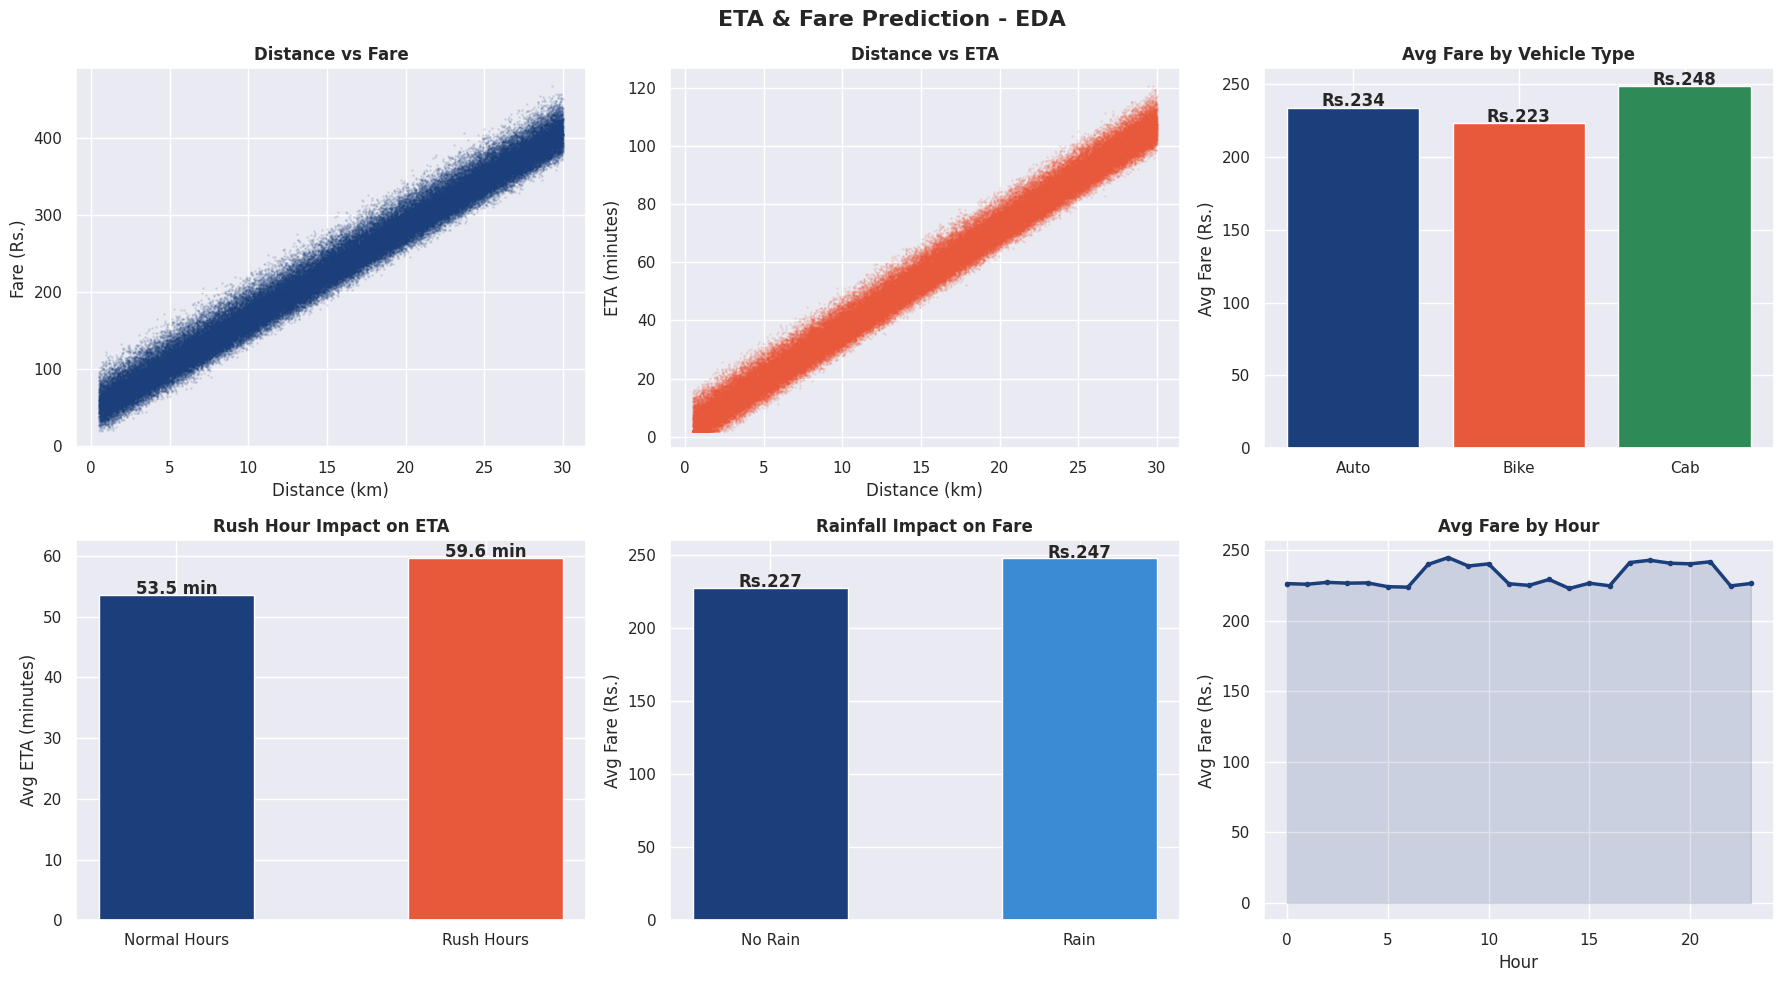

Training ETA model...
ETA  — MAE: 1.69 min  |  R²: 0.9950
Training Fare model...
Fare — MAE: Rs.6.85  |  R²: 0.9931

Both models trained ✅


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="darkgrid")

# ── EDA ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('ETA & Fare Prediction - EDA', fontsize=16, fontweight='bold')

# 1. Distance vs Fare
axes[0,0].scatter(df['distance_km'], df['fare_rs'],
                  alpha=0.1, s=1, color='#1B3F7A')
axes[0,0].set_title('Distance vs Fare', fontweight='bold')
axes[0,0].set_xlabel('Distance (km)')
axes[0,0].set_ylabel('Fare (Rs.)')

# 2. Distance vs ETA
axes[0,1].scatter(df['distance_km'], df['eta_minutes'],
                  alpha=0.1, s=1, color='#E8593C')
axes[0,1].set_title('Distance vs ETA', fontweight='bold')
axes[0,1].set_xlabel('Distance (km)')
axes[0,1].set_ylabel('ETA (minutes)')

# 3. Vehicle type vs Fare
vehicle_fare = df.groupby('vehicle_type')['fare_rs'].mean()
axes[0,2].bar(vehicle_fare.index, vehicle_fare.values,
              color=['#1B3F7A','#E8593C','#2E8B57'], edgecolor='white')
axes[0,2].set_title('Avg Fare by Vehicle Type', fontweight='bold')
axes[0,2].set_ylabel('Avg Fare (Rs.)')
for i, v in enumerate(vehicle_fare.values):
    axes[0,2].text(i, v+1, f'Rs.{v:.0f}', ha='center', fontweight='bold')

# 4. Rush hour impact on ETA
rush_eta = df.groupby('is_rush_hour')['eta_minutes'].mean()
axes[1,0].bar(['Normal Hours', 'Rush Hours'], rush_eta.values,
              color=['#1B3F7A', '#E8593C'], edgecolor='white', width=0.5)
axes[1,0].set_title('Rush Hour Impact on ETA', fontweight='bold')
axes[1,0].set_ylabel('Avg ETA (minutes)')
for i, v in enumerate(rush_eta.values):
    axes[1,0].text(i, v+0.2, f'{v:.1f} min', ha='center', fontweight='bold')

# 5. Rainfall impact on Fare
rain_fare = df.groupby('rainfall')['fare_rs'].mean()
axes[1,1].bar(['No Rain', 'Rain'], rain_fare.values,
              color=['#1B3F7A', '#3B8BD4'], edgecolor='white', width=0.5)
axes[1,1].set_title('Rainfall Impact on Fare', fontweight='bold')
axes[1,1].set_ylabel('Avg Fare (Rs.)')
for i, v in enumerate(rain_fare.values):
    axes[1,1].text(i, v+0.5, f'Rs.{v:.0f}', ha='center', fontweight='bold')

# 6. Hourly avg fare
hourly_fare = df.groupby('hour')['fare_rs'].mean()
axes[1,2].plot(hourly_fare.index, hourly_fare.values,
               color='#1B3F7A', linewidth=2.5, marker='o', markersize=3)
axes[1,2].fill_between(hourly_fare.index, hourly_fare.values, alpha=0.15, color='#1B3F7A')
axes[1,2].set_title('Avg Fare by Hour', fontweight='bold')
axes[1,2].set_xlabel('Hour')
axes[1,2].set_ylabel('Avg Fare (Rs.)')

plt.tight_layout()
plt.savefig('eda_eta_fare.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Features ──
features = [
    'distance_km', 'hour', 'day_of_week', 'is_weekend',
    'is_rush_hour', 'rainfall', 'temperature', 'is_holiday',
    'vehicle_encoded', 'zone_encoded'
]

# ── Train ETA Model ──
print("Training ETA model...")
X = df[features]
X_train, X_test, y_train, y_test = train_test_split(
    X, df['eta_minutes'], test_size=0.2, random_state=42
)
eta_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
eta_model.fit(X_train, y_train)
eta_pred = eta_model.predict(X_test)
eta_mae  = mean_absolute_error(y_test, eta_pred)
eta_r2   = r2_score(y_test, eta_pred)
print(f"ETA  — MAE: {eta_mae:.2f} min  |  R²: {eta_r2:.4f}")

# ── Train Fare Model ──
print("Training Fare model...")
X_train, X_test, y_train, y_test = train_test_split(
    X, df['fare_rs'], test_size=0.2, random_state=42
)
fare_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
fare_model.fit(X_train, y_train)
fare_pred = fare_model.predict(X_test)
fare_mae  = mean_absolute_error(y_test, fare_pred)
fare_r2   = r2_score(y_test, fare_pred)
print(f"Fare — MAE: Rs.{fare_mae:.2f}  |  R²: {fare_r2:.4f}")

print("\nBoth models trained ✅")

In [4]:
import pickle
import json

# ── Save Models ──
with open('eta_model.pkl', 'wb') as f:
    pickle.dump(eta_model, f)

with open('fare_model.pkl', 'wb') as f:
    pickle.dump(fare_model, f)

# ── Save feature list ──
model_info = {
    "features": features,
    "vehicle_map": {"Bike": 0, "Auto": 1, "Cab": 2},
    "zone_map": {"Downtown": 0, "Airport": 1, "Suburbs": 2,
                 "University": 3, "Mall": 4, "Station": 5},
    "eta_model": {"algorithm": "Random Forest", "MAE": round(eta_mae, 2), "R2": round(eta_r2, 4)},
    "fare_model": {"algorithm": "Random Forest", "MAE": round(fare_mae, 2), "R2": round(fare_r2, 4)}
}

with open('model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print("All saved ✅")
print(f"\nETA  model — MAE: {eta_mae:.2f} min  | R²: {eta_r2:.4f}")
print(f"Fare model — MAE: Rs.{fare_mae:.2f} | R²: {fare_r2:.4f}")
print("\nProject 3 - Part 1 COMPLETE ✅")
print("Now download files and move to VS Code for Streamlit app!")

All saved ✅

ETA  model — MAE: 1.69 min  | R²: 0.9950
Fare model — MAE: Rs.6.85 | R²: 0.9931

Project 3 - Part 1 COMPLETE ✅
Now download files and move to VS Code for Streamlit app!


In [5]:
from google.colab import files
files.download('eta_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
from google.colab import files
files.download('fare_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
from google.colab import files
files.download('model_info.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
from google.colab import files
files.download('eda_eta_fare.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>